# Pandas and NumPy Assignment - Part A (pandas)

**IT Services Ticket Data**

Notebook 1 of 2. Every cell is numbered with its question number.
Run the cells in order from the top - each one builds on the cleaning done above it.

**On Google Colab:** run cell Q0 first and upload `it_services_tickets_raw.csv` when it asks.
If you would rather read it from Google Drive, replace cell Q0 with:

```python
from google.colab import drive
drive.mount('/content/drive')
CSV = '/content/drive/MyDrive/it_services_tickets_raw.csv'
```


In [1]:
# Q0 - get the data file into Colab
# Run this cell first. If the file is not already next to the notebook it will
# ask you to upload it, so pick it_services_tickets_raw.csv from your computer.
import os

CSV = "it_services_tickets_raw.csv"

if not os.path.exists(CSV):
    from google.colab import files
    uploaded = files.upload()
    CSV = list(uploaded.keys())[0]

print("Using data file:", CSV)
print("Size (MB):", round(os.path.getsize(CSV) / 1024 / 1024, 2))


Using data file: it_services_tickets_raw.csv
Size (MB): 14.84


## Setup

In [2]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

pd.set_option("display.width", 118)
pd.set_option("display.max_columns", 10)
pd.set_option("display.max_colwidth", 30)
print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 2.2.2 | numpy 1.26.4


### Q1. Read the file it_services_tickets_raw.csv into a DataFrame called df.

In [3]:
# Q1
df = pd.read_csv(CSV)
print(type(df))
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
(49588, 29)


### Q2. Show the first 10 rows.

In [4]:
# Q2
print(df.head(10))

  Record_ID   ticket id ClientID              Client Name  client_industry  ... SLA_Hours resolution time hours  \
0     10842  TCK-999513   CL1003              Auric Motors      Automotive  ...        24                 27.30   
1     15782  TCK-481132   CL1014     \tTidewater Utilities       Utilities  ...         4                  2.65   
2      5278  TCK-840641   CL1009                Kite Foods            Fmcg  ...        72                   NaN   
3     35045  TCK-490788   CL1007    Pioneer Health Systems      Healthcare  ...  24 hours                 33.54   
4     34707  TCK-652326   CL1012           Orchid Airlines        Aviation  ...        24                   NaN   
5      6244  TCK-399139   CL1004    Blue Harbour Logistics       Logistics  ...        72                   NaN   
6     29182  TCK-646921   CL1000            Northwind Bank         Banking  ...        72                 93.48   
7     30044  TCK-347822   CL1024           Sundial Apparel         Apparel  ... 

### Q3. Show the last 10 rows.

In [5]:
# Q3
print(df.tail(10))

      Record_ID   ticket id ClientID          Client Name  client_industry  ... SLA_Hours resolution time hours  \
49578     42390  TCK-954753   CL1028        Ironclad Steel          Metals  ...        72                   NaN   
49579     23150  TCK-715409   CL1008    MERIDIAN INSURANCE       Insurance  ...         8                   NaN   
49580     14359  TCK-501895   CL1008  Meridian Insurance         Insurance  ...         4                   NaN   
49581     36564  TCK-586687   CL1020        Fjord Maritime        Shipping  ...         4                  7.48   
49582     24662  TCK-417633   CL1023    Everline Education       Education  ...        72                 86.86   
49583      1727  TCK-954774   CL1008    Meridian Insurance       Insurance  ...         8                  5.17   
49584      3851  TCK-760415   CL1015         Sierra Mining          Mining  ...        72                 46.25   
49585     13275  TCK-393895   CL1003          Auric Motors      Automotive  ... 

### Q4. Print how many rows and how many columns the table has.

In [6]:
# Q4
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 49588
Columns: 29


### Q5. Print the names of all the columns.

In [7]:
# Q5
for i, col in enumerate(df.columns, start=1):
    print(i, repr(col))

1 'Record_ID'
2 'ticket id'
3 'ClientID'
4 'Client Name '
5 'client_industry'
6 'Client_Country'
7 'client city'
8 'Contract Type'
9 'ServiceLine'
10 'project_code'
11 'Engagement Start Date'
12 'engagement_end_date '
13 'Ticket_Created_At'
14 'ticket resolved at'
15 'PRIORITY'
16 'Status'
17 'category '
18 'Assigned Engineer'
19 'engineer_Email'
20 'EngineerLevel'
21 'engineer_experience_years'
22 'Billing Rate (USD)'
23 'hours_logged'
24 'Billable Amount USD'
25 'SLA_Hours'
26 'resolution time hours'
27 'SLA Breached'
28 'CSAT Score'
29 'Customer Comment'


### Q6. Print the data type of each column.

In [8]:
# Q6
print(df.dtypes)

Record_ID                    object
ticket id                    object
ClientID                     object
Client Name                  object
client_industry              object
Client_Country               object
client city                  object
Contract Type                object
ServiceLine                  object
project_code                 object
Engagement Start Date        object
engagement_end_date          object
Ticket_Created_At            object
ticket resolved at           object
PRIORITY                     object
Status                       object
category                     object
Assigned Engineer            object
engineer_Email               object
EngineerLevel                object
engineer_experience_years    object
Billing Rate (USD)           object
hours_logged                 object
Billable Amount USD          object
SLA_Hours                    object
resolution time hours        object
SLA Breached                 object
CSAT Score                  

### Q7. Run df.info() and write one line about what it tells you.

In [9]:
# Q7
df.info()

# What it tells you: the number of rows, then for every column its non-null
# count, its dtype and the memory it uses. The gap between the non-null count
# and the total row count is exactly how much data is missing in that column.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49588 entries, 0 to 49587
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Record_ID                  48614 non-null  object
 1   ticket id                  49588 non-null  object
 2   ClientID                   49588 non-null  object
 3   Client Name                49588 non-null  object
 4   client_industry            49588 non-null  object
 5   Client_Country             49588 non-null  object
 6   client city                49588 non-null  object
 7   Contract Type              49588 non-null  object
 8   ServiceLine                49588 non-null  object
 9   project_code               49588 non-null  object
 10  Engagement Start Date      48742 non-null  object
 11  engagement_end_date        46431 non-null  object
 12  Ticket_Created_At          48991 non-null  object
 13  ticket resolved at         31993 non-null  object
 14  PRIORI

### Q8. Run df.describe() and look at the numeric columns.

In [10]:
# Q8
print(df.describe())

       Record_ID   ticket id ClientID            Client Name  client_industry  ... SLA_Hours resolution time hours  \
count      48614       49588    49588                   49588           49588  ...     49036                 32036   
unique     46220       45859       31                     509              91  ...        15                  9631   
top        39383  TCK-931581   CL1012  Pioneer Health Systems      Healthcare  ...        24                         
freq           4           4     1762                    1350            1585  ...     11725                   200   

       SLA Breached CSAT Score               Customer Comment  
count         48437      29771                          40701  
unique           19         25                             97  
top              no          1  "Excellent support", said ...  
freq           4648       6643                           1782  

[4 rows x 29 columns]


### Q9. Change all column names to lowercase, and replace spaces with underscores.

In [11]:
# Q9
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
print(list(df.columns))

['record_id', 'ticket_id', 'clientid', 'client_name', 'client_industry', 'client_country', 'client_city', 'contract_type', 'serviceline', 'project_code', 'engagement_start_date', 'engagement_end_date', 'ticket_created_at', 'ticket_resolved_at', 'priority', 'status', 'category', 'assigned_engineer', 'engineer_email', 'engineerlevel', 'engineer_experience_years', 'billing_rate_(usd)', 'hours_logged', 'billable_amount_usd', 'sla_hours', 'resolution_time_hours', 'sla_breached', 'csat_score', 'customer_comment']


### Q10. Print how many missing values each column has.

In [12]:
# Q10
print(df.isnull().sum())

record_id                      974
ticket_id                        0
clientid                         0
client_name                      0
client_industry                  0
client_country                   0
client_city                      0
contract_type                    0
serviceline                      0
project_code                     0
engagement_start_date          846
engagement_end_date           3157
ticket_created_at              597
ticket_resolved_at           17595
priority                       856
status                           0
category                       561
assigned_engineer             1171
engineer_email                1363
engineerlevel                  886
engineer_experience_years     1946
billing_rate_(usd)            1377
hours_logged                  1698
billable_amount_usd           2219
sla_hours                      552
resolution_time_hours        17552
sla_breached                  1151
csat_score                   19817
customer_comment    

### Q11. Print the total number of missing values in the whole table.

In [13]:
# Q11
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 83205


### Q12. Replace the text values NA, N/A, null and - with proper missing values.

In [14]:
# Q12
missing_tokens = ["NA", "N/A", "null", "-", "NULL", "na", "n/a", "None", "none",
                  "nan", "NaN", "#N/A", "missing", "?", "--", ""]

text_cols = df.select_dtypes(include="object").columns
df[text_cols] = df[text_cols].apply(lambda col: col.str.replace("\t", " ", regex=False).str.strip())

# the file also contains 4 repeated header rows in the middle of the data
df = df[df["record_id"] != "Record_ID"]

df = df.replace(missing_tokens, np.nan)
print(df.isnull().sum())
print("Total missing values now:", df.isnull().sum().sum())

record_id                      974
ticket_id                        0
clientid                         0
client_name                      0
client_industry                  0
client_country                   0
client_city                      0
contract_type                    0
serviceline                      0
project_code                     0
engagement_start_date         1519
engagement_end_date           5498
ticket_created_at             1047
ticket_resolved_at           18437
priority                      1522
status                           0
category                       959
assigned_engineer             2016
engineer_email                2456
engineerlevel                 1493
engineer_experience_years     3457
billing_rate_(usd)            2492
hours_logged                  3014
billable_amount_usd           3981
sla_hours                      990
resolution_time_hours        18621
sla_breached                  1996
csat_score                   25239
customer_comment    

### Q13. Count how many duplicate rows there are.

In [15]:
# Q13
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 1564


### Q14. Remove the duplicate rows and print the new number of rows.

In [16]:
# Q14
df = df.drop_duplicates().reset_index(drop=True)
print("Rows after removing duplicates:", len(df))

Rows after removing duplicates: 48020


### Q15. Show only three columns: ticket id, client name and status.

In [17]:
# Q15
print(df[["ticket_id", "client_name", "status"]].head(10))

    ticket_id             client_name       status
0  TCK-999513            Auric Motors     Resolved
1  TCK-481132     Tidewater Utilities     Resolved
2  TCK-840641              Kite Foods         open
3  TCK-490788  Pioneer Health Systems     Resolved
4  TCK-652326         Orchid Airlines         OPEN
5  TCK-399139  Blue Harbour Logistics  IN PROGRESS
6  TCK-646921          Northwind Bank     RESOLVED
7  TCK-347822         Sundial Apparel     Resolved
8  TCK-313166          Willow Biotech     Resolved
9  TCK-874804  Pioneer Health Systems       CLOSED


### Q16. Show rows 5 to 15 using iloc.

In [18]:
# Q16
print(df.iloc[5:16])

   record_id   ticket_id clientid             client_name  client_industry  ... sla_hours resolution_time_hours  \
5       6244  TCK-399139   CL1004  Blue Harbour Logistics        Logistics  ...        72                   NaN   
6      29182  TCK-646921   CL1000          Northwind Bank          Banking  ...        72                 93.48   
7      30044  TCK-347822   CL1024         Sundial Apparel          Apparel  ...        24                  8.55   
8      28485  TCK-313166   CL1027          Willow Biotech    Biotechnology  ...         4                  1.86   
9       5489  TCK-874804   CL1007  Pioneer Health Systems       Healthcare  ...        72                 35.27   
10     36019  TCK-786877   CL1009              Kite Foods             FMCG  ...         4                  7.53   
11     23623  TCK-939913   CL1002           Vertex Pharma  Pharmaceuticals  ...         4                  1.92   
12      6130  TCK-436529   CL1001     Helios Retail Group           Retail  ... 

### Q17. Show the row at index 100 using loc.

In [19]:
# Q17
print(df.loc[100])

record_id                                            19100
ticket_id                                       TCK-316040
clientid                                            CL1019
client_name                               Redstone Defence
client_industry                                  Aerospace
client_country                                          US
client_city                                     Huntsville
contract_type                                     RETAINER
serviceline                                 Cloud & DevOps
project_code                                   PRJ884-2024
engagement_start_date                              1556668
engagement_end_date                            31-Dec-2022
ticket_created_at                      01/21/2021 12:02 PM
ticket_resolved_at                     2021-01-22T23:20:26
priority                                                 3
status                                            resolved
category                                       Enhanceme

### Q18. Show all the tickets where priority is P1.

In [20]:
# Q18
prio = df["priority"].str.strip().str.upper()
p1 = df[prio.str.startswith("P1", na=False) | prio.isin(["1", "CRITICAL"])]
print("P1 tickets:", len(p1))
print(p1[["ticket_id", "client_name", "priority", "status"]].head(10))

P1 tickets: 11687
     ticket_id             client_name       priority    status
1   TCK-481132     Tidewater Utilities             p1  Resolved
8   TCK-313166          Willow Biotech       Critical  Resolved
10  TCK-786877              Kite Foods             p1    Closed
11  TCK-939913           Vertex Pharma  P1 - Critical    Closed
16  TCK-610531        Redstone Defence              1    Closed
28  TCK-343310  Pioneer Health Systems             p1  resolved
32  TCK-184177          Fjord Maritime             p1    Closed
35  TCK-818951     Atlas Manufacturing             P1      open
39  TCK-978079      Meridian Insurance              1    closed
40  TCK-686248          Willow Biotech              1  resolved


### Q19. Show all the tickets where status is Open.

In [21]:
# Q19
st = df["status"].str.strip().str.lower()
open_tickets = df[st == "open"]
print("Open tickets:", len(open_tickets))
print(open_tickets[["ticket_id", "client_name", "priority", "status"]].head(10))

Open tickets: 6683
     ticket_id          client_name  priority status
2   TCK-840641           Kite Foods        p4   open
4   TCK-652326      Orchid Airlines    MEDIUM   OPEN
24  TCK-203182      Saffron Telecom       LOW   open
30  TCK-995122       Ironclad Steel       LOW   OPEN
33  TCK-795642      Orchid Airlines       low   OPEN
34  TCK-307213        Vertex Pharma        p3   Open
35  TCK-818951  Atlas Manufacturing        P1   open
43  TCK-788914           Kite Foods  Critical   OPEN
45  TCK-515728        Vertex Pharma        P3   Open
52  TCK-828134       Ironclad Steel      HIGH   OPEN


### Q20. Count how many tickets there are for each status.

In [22]:
# Q20
status_map = {
    "resolved": "Resolved", "closed": "Closed", "auto-closed": "Closed",
    "open": "Open", "in progress": "In Progress", "in-progress": "In Progress",
    "wip": "In Progress", "on hold": "On Hold", "on-hold": "On Hold",
    "pending customer": "On Hold", "cancelled": "Cancelled", "canceled": "Cancelled",
}
df["status"] = df["status"].str.strip().str.lower().map(status_map)
print(df["status"].value_counts(dropna=False))

status
Resolved       16428
Closed         14932
Open            6683
In Progress     6238
On Hold         2350
Cancelled       1389
Name: count, dtype: int64


### Q21. Count how many tickets there are for each priority.

In [23]:
# Q21
def clean_priority(value):
    if pd.isna(value):
        return np.nan
    t = str(value).strip().upper()
    if "P1" in t or t in ("1", "CRITICAL"):
        return "P1"
    if "P2" in t or t in ("2", "HIGH"):
        return "P2"
    if "P3" in t or t in ("3", "MEDIUM"):
        return "P3"
    if "P4" in t or t in ("4", "LOW"):
        return "P4"
    return np.nan

df["priority"] = df["priority"].map(clean_priority)
print(df["priority"].value_counts(dropna=False))

priority
P3     11760
P1     11687
P2     11668
P4     11425
NaN     1480
Name: count, dtype: int64


### Q22. Count how many tickets there are for each service line.

In [24]:
# Q22
df["serviceline"] = df["serviceline"].str.strip().str.title()
print(df["serviceline"].value_counts(dropna=False))

serviceline
Application Support          4890
Application Development      4849
Cybersecurity                4848
Infrastructure Management    4840
Data & Analytics             4800
Quality Engineering          4780
Network Operations           4771
Cloud & Devops               4751
Erp Services                 4748
Service Desk                 4743
Name: count, dtype: int64


### Q23. Find how many different clients there are.

In [25]:
# Q23
print("Different client IDs:", df["clientid"].nunique())
print("Different client name spellings (before cleaning):", df["client_name"].nunique())

Different client IDs: 30
Different client name spellings (before cleaning): 90


### Q24. Print the list of all countries in the data.

In [26]:
# Q24
country_fix = {"Us": "USA", "Usa": "USA", "U.S.A.": "USA", "United States": "USA",
               "Uk": "UK", "U.K.": "UK", "United Kingdom": "UK", "Great Britain": "UK"}
df["client_country"] = df["client_country"].str.strip().str.title().replace(country_fix)
print(sorted(df["client_country"].dropna().unique()))
print("Number of countries:", df["client_country"].nunique())

['Australia', 'Bangladesh', 'Brazil', 'Canada', 'France', 'Germany', 'India', 'Ireland', 'Japan', 'Mexico', 'Netherlands', 'Norway', 'Singapore', 'Spain', 'Switzerland', 'Taiwan', 'UK', 'USA', 'United Arab Emirates']
Number of countries: 19


### Q25. Convert the hours logged column to a number.

In [27]:
# Q25
df["hours_logged"] = pd.to_numeric(
    df["hours_logged"].str.replace("hrs", "", regex=False)
                      .str.replace("hr", "", regex=False)
                      .str.strip(),
    errors="coerce")
print(df["hours_logged"].dtype)
print(df["hours_logged"].head())
print("Values that could not be converted:", df["hours_logged"].isna().sum())

float64
0      NaN
1     1.34
2     7.00
3    34.63
4    12.76
Name: hours_logged, dtype: float64
Values that could not be converted: 2914


### Q26. Convert the billing rate column to a number. Remove the $ sign first.

In [28]:
# Q26
df["billing_rate_(usd)"] = pd.to_numeric(
    df["billing_rate_(usd)"].str.replace("$", "", regex=False)
                            .str.replace("USD", "", regex=False)
                            .str.replace(",", "", regex=False)
                            .str.strip(),
    errors="coerce")
print(df["billing_rate_(usd)"].dtype)
print(df["billing_rate_(usd)"].describe())

float64


count    45613.000000
mean       111.576691
std        723.941095
min        -45.000000
25%         34.900000
50%         57.740000
75%         89.480000
max      12500.000000
Name: billing_rate_(usd), dtype: float64


### Q27. Convert the CSAT score column to a number.

In [29]:
# Q27
df["csat_score"] = pd.to_numeric(df["csat_score"], errors="coerce")
print(df["csat_score"].dtype)
print(df["csat_score"].value_counts().sort_index())

float64
csat_score
-1.0       91
 0.0      100
 1.0     6937
 2.0     4662
 3.0     4639
 4.0     3895
 5.0     3115
 9.0       69
 10.0      82
Name: count, dtype: int64


### Q28. Print the average, the smallest and the largest value of hours logged.

In [30]:
# Q28
print("Average:", round(df["hours_logged"].mean(), 2))
print("Minimum:", df["hours_logged"].min())
print("Maximum:", df["hours_logged"].max())

Average: 62.54
Minimum: -12.5
Maximum: 9888.01


### Q29. Sort the table by hours logged from highest to lowest and show the top 10 rows.

In [31]:
# Q29
top_hours = df.sort_values("hours_logged", ascending=False)
print(top_hours[["ticket_id", "client_name", "serviceline", "hours_logged"]].head(10))

        ticket_id             client_name                serviceline  hours_logged
12971  TCK-653078           vertex pharma        Application Support       9888.01
10032  TCK-653078           Vertex Pharma        Application Support       9888.01
14484  TCK-473608              Kite Foods  Infrastructure Management       8760.00
28654  TCK-836693             Lumen Media               Service Desk       8760.00
35038  TCK-835112        Redstone Defence    Application Development       8760.00
25050  TCK-876581         Palisade Realty           Data & Analytics       8760.00
45453  TCK-423490           Vertex Pharma               Service Desk       8760.00
35063  TCK-542106  Beacon Public Services    Application Development       8760.00
27857  TCK-588710         Palisade Realty         Network Operations       8760.00
39463  TCK-858893          Cascade Energy        Quality Engineering       8760.00


### Q30. Show the 5 tickets with the highest billable amount.

In [32]:
# Q30
df["billable_amount_usd"] = pd.to_numeric(
    df["billable_amount_usd"].str.replace("$", "", regex=False)
                             .str.replace("USD", "", regex=False)
                             .str.replace(",", "", regex=False)
                             .str.strip(),
    errors="coerce")
print(df.nlargest(5, "billable_amount_usd")[
    ["ticket_id", "client_name", "hours_logged", "billing_rate_(usd)", "billable_amount_usd"]])

        ticket_id            client_name  hours_logged  billing_rate_(usd)  billable_amount_usd
5007   TCK-289309  Zephyr Semiconductors        4859.2              9999.0           48587340.8
25850  TCK-289309  ZEPHYR SEMICONDUCTORS        4859.2              9999.0           48587340.8
12239  TCK-666074        Palisade Realty         205.2                 NaN            2564625.0
41551  TCK-502127         Northwind Bank         163.0             12500.0            2043250.0
13148  TCK-439485        Granite Capital         128.0             12500.0            1589681.6


### Q31. Remove the extra spaces from the client name column.

In [33]:
# Q31
df["client_name"] = (df["client_name"].str.replace("\t", " ", regex=False)
                                      .str.replace(r"\s+", " ", regex=True)
                                      .str.strip())
print(df["client_name"].nunique(), "different spellings left")

90 different spellings left


### Q32. Change the client name column to title case.

In [34]:
# Q32
df["client_name"] = df["client_name"].str.title()
print(df["client_name"].nunique(), "different client names")
print(sorted(df["client_name"].dropna().unique()))

30 different client names
['Atlas Manufacturing', 'Auric Motors', 'Beacon Public Services', 'Blue Harbour Logistics', 'Cascade Energy', 'Copperleaf Agro', 'Everline Education', 'Fjord Maritime', 'Granite Capital', 'Halcyon Hotels', 'Helios Retail Group', 'Ironclad Steel', 'Kite Foods', 'Lumen Media', 'Marlowe Legal', 'Meridian Insurance', 'Nimbus Cloudworks', 'Northwind Bank', 'Orchid Airlines', 'Palisade Realty', 'Pioneer Health Systems', 'Quarry Construction', 'Redstone Defence', 'Saffron Telecom', 'Sierra Mining', 'Sundial Apparel', 'Tidewater Utilities', 'Vertex Pharma', 'Willow Biotech', 'Zephyr Semiconductors']


### Q33. Convert the ticket created column to a date.

In [35]:
# Q33
# step 1 - the normal text timestamps, in their several different layouts
created = pd.to_datetime(df["ticket_created_at"], format="mixed", errors="coerce")

# step 2 - some rows hold a number instead of a date (e.g. 1642809).
# These are unix timestamps with the last 3 digits chopped off,
# so multiplying by 1000 turns them back into real dates.
codes = pd.to_numeric(df["ticket_created_at"], errors="coerce")
codes = codes.where(codes.between(1_000_000, 2_000_000))
created = created.fillna(pd.to_datetime(codes * 1000, unit="s"))

df["ticket_created_at"] = created
print(df["ticket_created_at"].dtype)
print(df["ticket_created_at"].head())
print("Could not be parsed:", df["ticket_created_at"].isna().sum())
print("Range:", df["ticket_created_at"].min(), "to", df["ticket_created_at"].max())

datetime64[ns]
0   2021-02-26 13:04:00
1   2022-08-02 00:05:32
2   2022-12-01 04:54:11
3   2024-04-09 07:01:00
4   2022-08-09 12:52:11
Name: ticket_created_at, dtype: datetime64[ns]
Could not be parsed: 1018
Range: 2019-01-03 12:49:00 to 2027-11-23 22:20:00


### Q34. Add a new column that holds the year of the ticket.

In [36]:
# Q34
df["ticket_year"] = df["ticket_created_at"].dt.year
print(df[["ticket_id", "ticket_created_at", "ticket_year"]].head())

    ticket_id   ticket_created_at  ticket_year
0  TCK-999513 2021-02-26 13:04:00       2021.0
1  TCK-481132 2022-08-02 00:05:32       2022.0
2  TCK-840641 2022-12-01 04:54:11       2022.0
3  TCK-490788 2024-04-09 07:01:00       2024.0
4  TCK-652326 2022-08-09 12:52:11       2022.0


### Q35. Add a new column that holds the month of the ticket.

In [37]:
# Q35
df["ticket_month"] = df["ticket_created_at"].dt.month
print(df[["ticket_id", "ticket_created_at", "ticket_year", "ticket_month"]].head())

    ticket_id   ticket_created_at  ticket_year  ticket_month
0  TCK-999513 2021-02-26 13:04:00       2021.0           2.0
1  TCK-481132 2022-08-02 00:05:32       2022.0           8.0
2  TCK-840641 2022-12-01 04:54:11       2022.0          12.0
3  TCK-490788 2024-04-09 07:01:00       2024.0           4.0
4  TCK-652326 2022-08-09 12:52:11       2022.0           8.0


### Q36. Count how many tickets were created in each year.

In [38]:
# Q36
print(df["ticket_year"].value_counts(dropna=False).sort_index())

ticket_year
2019.0    3036
2020.0    6734
2021.0    8675
2022.0    9357
2023.0    9482
2024.0    6187
2025.0    2576
2026.0     831
2027.0     124
NaN       1018
Name: count, dtype: int64


### Q37. Add a new column called total equal to billing rate multiplied by hours logged.

In [39]:
# Q37
df["total"] = df["billing_rate_(usd)"] * df["hours_logged"]
print(df[["ticket_id", "billing_rate_(usd)", "hours_logged", "total",
          "billable_amount_usd"]].head(10))

    ticket_id  billing_rate_(usd)  hours_logged      total  billable_amount_usd
0  TCK-999513               39.45           NaN        NaN              1089.21
1  TCK-481132               33.15          1.34    44.4210                44.40
2  TCK-840641               48.10          7.00   336.7000                  NaN
3  TCK-490788               52.98         34.63  1834.6974              1834.70
4  TCK-652326               22.90         12.76   292.2040               292.50
5  TCK-399139              119.50         15.30  1828.3500              1827.70
6  TCK-646921               74.80           NaN        NaN              4609.30
7  TCK-347822               48.06          9.00   432.5400               420.50
8  TCK-313166               72.37          1.66   120.1342               120.13
9  TCK-874804               28.23         11.10   313.3530               312.22


### Q38. Fill the missing values in the CSAT score column with the average CSAT score.

In [40]:
# Q38
mean_csat = df["csat_score"].mean()
print("Average CSAT used to fill:", round(mean_csat, 2))
df["csat_score"] = df["csat_score"].fillna(mean_csat)
print("Missing CSAT after filling:", df["csat_score"].isna().sum())

Average CSAT used to fill: 2.66
Missing CSAT after filling: 0


### Q39. Drop the rows where the client name is missing.

In [41]:
# Q39
before = len(df)
df = df.dropna(subset=["client_name"])
print("Rows before:", before, "| Rows after:", len(df),
      "| Removed:", before - len(df))

Rows before: 48020 | Rows after: 48020 | Removed: 0


### Q40. Group by service line and find the average hours logged.

In [42]:
# Q40
print(df.groupby("serviceline")["hours_logged"].mean().round(2).sort_values(ascending=False))

serviceline
Service Desk                 74.32
Cybersecurity                68.16
Infrastructure Management    67.45
Network Operations           64.90
Application Development      64.62
Quality Engineering          62.90
Erp Services                 60.22
Data & Analytics             59.44
Application Support          55.44
Cloud & Devops               48.02
Name: hours_logged, dtype: float64


### Q41. Group by priority and count the tickets.

In [43]:
# Q41
print(df.groupby("priority")["ticket_id"].count())

priority
P1    11687
P2    11668
P3    11760
P4    11425
Name: ticket_id, dtype: int64


### Q42. Group by client name and find the total billable amount.

In [44]:
# Q42
totals = df.groupby("client_name")["billable_amount_usd"].sum().sort_values(ascending=False)
print(totals.round(2))

client_name
Zephyr Semiconductors     1.059014e+08
Pioneer Health Systems    1.108415e+07
Sundial Apparel           1.086827e+07
Palisade Realty           1.056783e+07
Vertex Pharma             9.746725e+06
Quarry Construction       8.327296e+06
Orchid Airlines           8.169335e+06
Lumen Media               8.165013e+06
Nimbus Cloudworks         8.131734e+06
Saffron Telecom           8.040011e+06
Northwind Bank            7.796928e+06
Ironclad Steel            7.623910e+06
Sierra Mining             7.556915e+06
Granite Capital           7.520156e+06
Marlowe Legal             7.098008e+06
Redstone Defence          6.937364e+06
Tidewater Utilities       6.837005e+06
Meridian Insurance        6.706688e+06
Beacon Public Services    6.695303e+06
Auric Motors              6.665137e+06
Kite Foods                6.661279e+06
Cascade Energy            6.536811e+06
Copperleaf Agro           6.498033e+06
Willow Biotech            6.426517e+06
Helios Retail Group       6.249926e+06
Fjord Maritim

### Q43. Find the top 5 clients by number of tickets.

In [45]:
# Q43
print(df["client_name"].value_counts().head(5))

client_name
Orchid Airlines           1693
Pioneer Health Systems    1686
Vertex Pharma             1672
Zephyr Semiconductors     1664
Everline Education        1653
Name: count, dtype: int64


### Q44. Find the average CSAT score for each priority.

In [46]:
# Q44
print(df.groupby("priority")["csat_score"].mean().round(2))

priority
P1    2.66
P2    2.65
P3    2.66
P4    2.66
Name: csat_score, dtype: float64


### Q45. Draw a bar chart of ticket count by service line.

serviceline
Application Support          4890
Application Development      4849
Cybersecurity                4848
Infrastructure Management    4840
Data & Analytics             4800
Quality Engineering          4780
Network Operations           4771
Cloud & Devops               4751
Erp Services                 4748
Service Desk                 4743
Name: count, dtype: int64


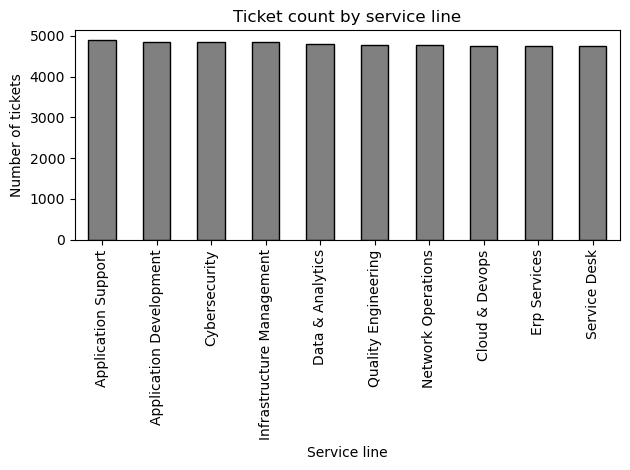

In [47]:
# Q45
counts = df["serviceline"].value_counts()
print(counts)

counts.plot(kind="bar", color="grey", edgecolor="black")
plt.title("Ticket count by service line")
plt.xlabel("Service line")
plt.ylabel("Number of tickets")
plt.tight_layout()
plt.show()

### Q46. Draw a histogram of hours logged.

count    45106.00
mean        62.54
std        483.21
min        -12.50
25%          4.34
50%         13.14
75%         29.54
max       9888.01
Name: hours_logged, dtype: float64


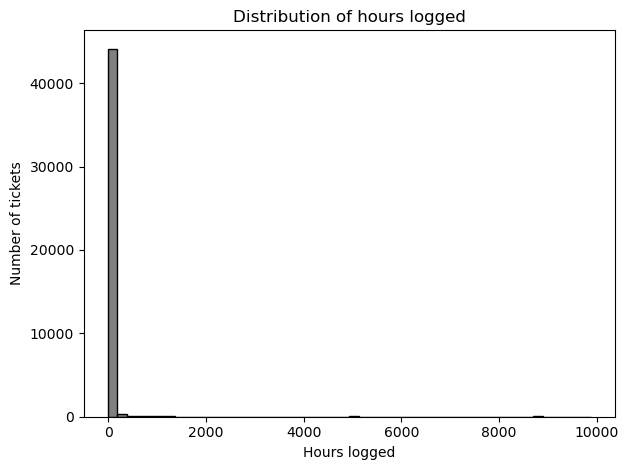

In [48]:
# Q46
print(df["hours_logged"].describe().round(2))

df["hours_logged"].plot(kind="hist", bins=50, color="grey", edgecolor="black")
plt.title("Distribution of hours logged")
plt.xlabel("Hours logged")
plt.ylabel("Number of tickets")
plt.tight_layout()
plt.show()

### Q47. Show only the tickets where hours logged is more than 50.

In [49]:
# Q47
long_tickets = df[df["hours_logged"] > 50]
print("Tickets over 50 hours:", len(long_tickets))
print(long_tickets[["ticket_id", "client_name", "serviceline", "hours_logged"]].head(10))

Tickets over 50 hours: 4532
     ticket_id             client_name                serviceline  hours_logged
13  TCK-386938          Cascade Energy  Infrastructure Management         72.31
18  TCK-241037           Sierra Mining        Application Support        253.85
20  TCK-604317         Orchid Airlines           Data & Analytics         50.81
22  TCK-664378          Halcyon Hotels              Cybersecurity         67.94
25  TCK-472151     Helios Retail Group    Application Development        541.30
38  TCK-345793     Atlas Manufacturing        Quality Engineering         63.02
44  TCK-709388  Pioneer Health Systems  Infrastructure Management         84.00
58  TCK-985181         Granite Capital           Data & Analytics        128.00
60  TCK-859212            Auric Motors    Application Development       1900.66
64  TCK-779468           Vertex Pharma           Data & Analytics        133.35


### Q48. Show the tickets where status is Closed and priority is P1.

In [50]:
# Q48
closed_p1 = df[(df["status"] == "Closed") & (df["priority"] == "P1")]
print("Closed P1 tickets:", len(closed_p1))
print(closed_p1[["ticket_id", "client_name", "priority", "status", "hours_logged"]].head(10))

Closed P1 tickets: 3646
     ticket_id             client_name priority  status  hours_logged
10  TCK-786877              Kite Foods       P1  Closed           NaN
11  TCK-939913           Vertex Pharma       P1  Closed          1.44
16  TCK-610531        Redstone Defence       P1  Closed          0.59
32  TCK-184177          Fjord Maritime       P1  Closed          3.42
39  TCK-978079      Meridian Insurance       P1  Closed          1.03
41  TCK-419753   Zephyr Semiconductors       P1  Closed          3.92
66  TCK-789057           Sierra Mining       P1  Closed          4.00
73  TCK-939070  Beacon Public Services       P1  Closed          1.00
91  TCK-287936     Quarry Construction       P1  Closed         10.91
93  TCK-388132          Willow Biotech       P1  Closed          3.81


### Q49. In the SLA breached column, change Yes, Y, TRUE and 1 to True, and everything else to False.

In [51]:
# Q49
true_values = ["yes", "y", "true", "1"]
df["sla_breached"] = df["sla_breached"].astype(str).str.strip().str.lower().isin(true_values)
print(df["sla_breached"].value_counts())
print("Breach rate:", round(df["sla_breached"].mean() * 100, 1), "%")

sla_breached
False    28694
True     19326
Name: count, dtype: int64
Breach rate: 40.2 %


### Q50. Save your cleaned table to a new CSV file.

In [52]:
# Q50
df.to_csv("it_services_tickets_clean.csv", index=False)
print("Saved it_services_tickets_clean.csv")
print("Shape:", df.shape)
print("File size (MB):", round(os.path.getsize("it_services_tickets_clean.csv") / 1024 / 1024, 2))

# On Colab, download the cleaned file to your computer with:
# from google.colab import files; files.download("it_services_tickets_clean.csv")

Saved it_services_tickets_clean.csv
Shape: (48020, 32)
File size (MB): 15.45
